# Chapter 34 — Ratios and Proportions

> **Prerequisites:** ch024 (Rational Numbers), ch022 (Natural Numbers)  
> **You will learn:**
> - Ratios as a precise language for comparing quantities
> - The cross-multiplication test for proportion equality
> - Direct vs inverse proportion and their computational signatures
> - Scaling laws: why big animals can't look like small ones
> - How ratios underlie aspect ratios, sampling rates, compression ratios, and model evaluation metrics
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **ratio** is a comparison of two quantities by division: `a : b = a/b`. It answers the question "how many times larger is `a` than `b`?"

A **proportion** is a statement that two ratios are equal: `a/b = c/d`, or equivalently `a:b :: c:d`.

These are among the most computationally prevalent mathematical structures:
- Performance metrics (precision, recall, F1) are all ratios
- Compression ratio = original size / compressed size
- Aspect ratio = width / height
- Signal-to-noise ratio (SNR) = signal power / noise power
- Learning rate schedules often decay as a ratio

**Precision and dimensionlessness:**  
Ratios are dimensionless. `5 meters / 2 meters = 2.5` — the units cancel. This makes ratios universally comparable: a compression ratio of 3:1 means the same thing whether the data is audio, images, or text.

**Common misconception:** "Ratio" and "fraction" are not the same. A fraction always represents part/whole; a ratio can compare any two quantities, including things that don't form a whole together (e.g., 3 red balls to 5 blue balls).

---

## 2. Intuition & Mental Models

**Geometric analogy — similar triangles:**  
Two triangles are similar if their corresponding side ratios are equal. A ratio is the shape without the size. Proportions encode scale-invariant relationships.

**Computational analogy — normalization:**  
When you normalize a vector or a dataset, you compute ratios: each element divided by the total or the maximum. The resulting values are scale-free — they describe shape, not magnitude.

**Direct proportion:** `y = k·x`. When x doubles, y doubles. The ratio y/x = k is constant. Linear functions through the origin are exactly direct proportions.

**Inverse proportion:** `y = k/x`. When x doubles, y halves. The product x·y = k is constant. This is why doubling clock frequency halves cycle time.

**Recall from ch024 (Rational Numbers):** A ratio `a:b` is just the rational number `a/b`. Everything we know about rational arithmetic applies directly.

---

## 3. Visualization

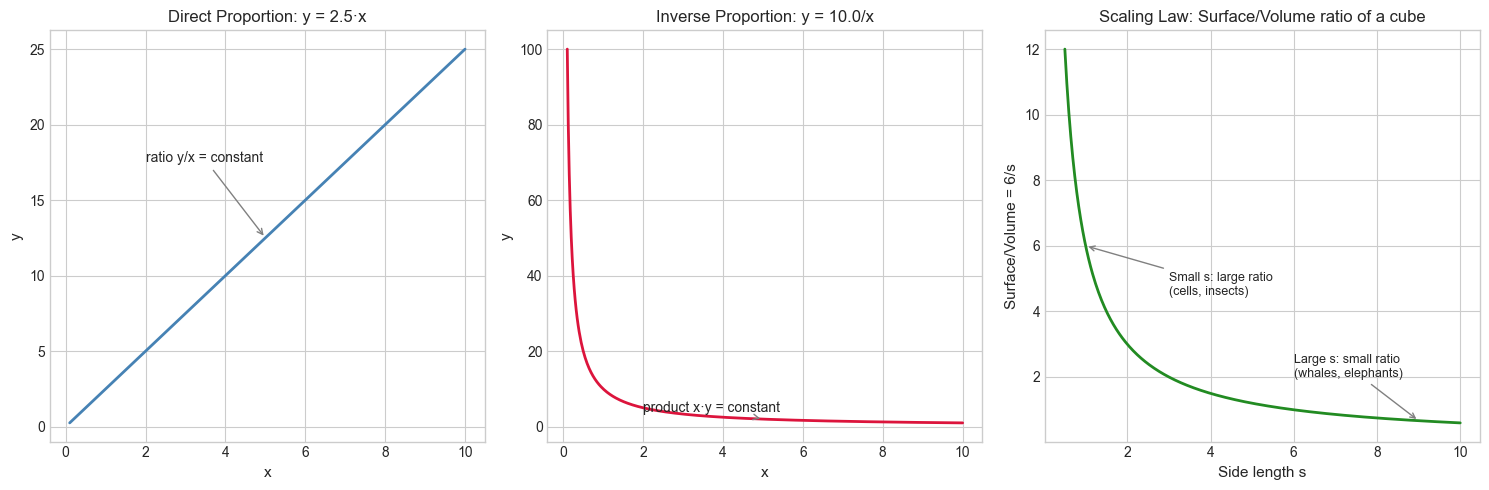

In [1]:
# --- Visualization: Direct vs Inverse proportion + scaling laws ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(0.1, 10, 400)

K_DIRECT  = 2.5   # <-- modify the proportionality constant
K_INVERSE = 10.0

y_direct  = K_DIRECT * x
y_inverse = K_INVERSE / x

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Direct proportion
axes[0].plot(x, y_direct, 'steelblue', linewidth=2)
axes[0].set_title(f'Direct Proportion: y = {K_DIRECT}·x', fontsize=12)
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('y', fontsize=11)
axes[0].annotate('ratio y/x = constant', xy=(5, K_DIRECT*5),
                 xytext=(2, K_DIRECT*7), arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=10)

# Inverse proportion
axes[1].plot(x, y_inverse, 'crimson', linewidth=2)
axes[1].set_title(f'Inverse Proportion: y = {K_INVERSE}/x', fontsize=12)
axes[1].set_xlabel('x', fontsize=11)
axes[1].set_ylabel('y', fontsize=11)
axes[1].annotate('product x·y = constant', xy=(5, K_INVERSE/5),
                 xytext=(2, K_INVERSE/2.5), arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=10)

# Scaling law: surface area vs volume for a cube (side length s)
# Surface ∝ s², Volume ∝ s³, so Surface/Volume ∝ 1/s
s = np.linspace(0.5, 10, 400)
surface = 6 * s**2
volume  = s**3
ratio   = surface / volume

axes[2].plot(s, ratio, 'forestgreen', linewidth=2)
axes[2].set_title('Scaling Law: Surface/Volume ratio of a cube', fontsize=12)
axes[2].set_xlabel('Side length s', fontsize=11)
axes[2].set_ylabel('Surface/Volume = 6/s', fontsize=11)
axes[2].annotate('Small s: large ratio\n(cells, insects)', xy=(1, 6),
                 xytext=(3, 4.5), arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9)
axes[2].annotate('Large s: small ratio\n(whales, elephants)', xy=(9, 6/9),
                 xytext=(6, 2), arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Cross-multiplication test:**  
Two ratios `a/b` and `c/d` are equal if and only if `a·d = b·c`. This avoids floating-point division when testing proportion with integers.

**Proportional scaling:**  
If `a/b = c/d` and we know three values, the fourth is determined:
```
d = b·c / a
```
This is the "rule of three" — the most common calculation in practical mathematics.

**Direct proportion:**
```
y ∝ x   ⟺   y = k·x   for constant k
```
The graph is a line through the origin. The slope `k` is the proportionality constant.

**Power law / allometric scaling:**  
Many natural quantities scale as power laws:
```
y = k · x^α
```
For α = 1: direct proportion. For α = −1: inverse proportion. For α = 2/3: common in biology (metabolic rate vs body mass).

On a log-log plot, a power law appears as a straight line with slope α:
```
log(y) = log(k) + α·log(x)
```
This is the primary reason log-log plots are used in science *(logarithms introduced in ch043)*.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Ratio arithmetic and proportion tools ---
import math

class Ratio:
    """
    Exact rational ratio a:b stored as integers.
    Automatically reduces to lowest terms.
    """
    def __init__(self, a, b):
        assert b != 0, "Denominator cannot be zero"
        g = math.gcd(abs(a), abs(b))
        sign = -1 if b < 0 else 1
        self.a = sign * a // g
        self.b = sign * b // g

    def __eq__(self, other):
        """Test equality via cross-multiplication (exact, no float)."""
        return self.a * other.b == self.b * other.a

    def __float__(self):
        return self.a / self.b

    def __mul__(self, other):
        return Ratio(self.a * other.a, self.b * other.b)

    def __truediv__(self, other):
        return Ratio(self.a * other.b, self.b * other.a)

    def scale_fourth(self, known_three):
        """
        Rule of three: if self == c/d, find d given c.
        known_three = c; returns d = c * self.b / self.a
        """
        c = known_three
        return Ratio(c * self.b, self.a)

    def __repr__(self):
        return f"{self.a}:{self.b}  ({float(self):.4f})"


# Demo
r1 = Ratio(3, 4)
r2 = Ratio(6, 8)
r3 = Ratio(9, 12)

print(f"3:4 = {r1}")
print(f"6:8 = {r2}")
print(f"3:4 == 6:8 ? {r1 == r2}")
print(f"3:4 == 9:12 ? {r1 == r3}")

print("\n--- Rule of three ---")
# If 3 apples cost $2, how much do 7 apples cost?
unit_cost = Ratio(2, 3)  # $2 per 3 apples
cost_of_7 = unit_cost.scale_fourth(7)
print(f"3 apples: $2 → 7 apples: ${float(cost_of_7):.4f}")

print("\n--- Aspect ratios ---")
ratios = [(16, 9), (4, 3), (21, 9), (1, 1)]
for w, h in ratios:
    r = Ratio(w, h)
    print(f"  {w}:{h} → reduced: {r}")

3:4 = 3:4  (0.7500)
6:8 = 3:4  (0.7500)
3:4 == 6:8 ? True
3:4 == 9:12 ? True

--- Rule of three ---
3 apples: $2 → 7 apples: $10.5000

--- Aspect ratios ---
  16:9 → reduced: 16:9  (1.7778)
  4:3 → reduced: 4:3  (1.3333)
  21:9 → reduced: 7:3  (2.3333)
  1:1 → reduced: 1:1  (1.0000)


Fitted power law: B = 0.3134 * M^1.135
Kleiber's Law predicts exponent ≈ 0.75


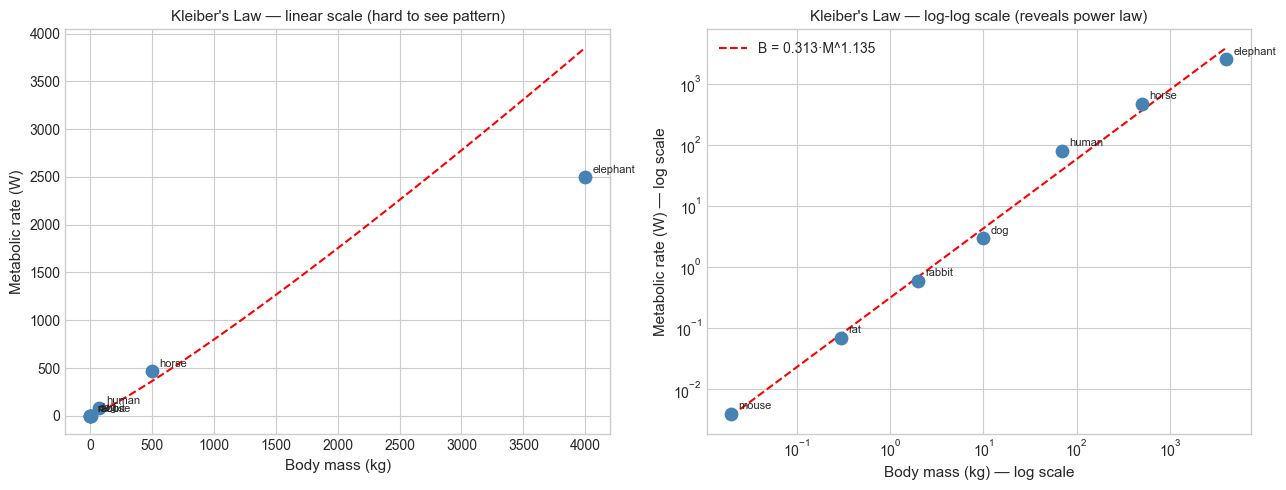

In [3]:
# --- Power law fitting via log-log linearization ---
import numpy as np
import matplotlib.pyplot as plt

# Kleiber's Law: metabolic rate B ≈ k * M^(3/4)
# where M = body mass (kg), B = metabolic rate (watts)
# Data: approximate values for real animals

animals = {
    'mouse':     (0.02, 0.004),
    'rat':       (0.3,  0.07),
    'rabbit':    (2.0,  0.6),
    'dog':       (10,   3.0),
    'human':     (70,   80),
    'horse':     (500,  470),
    'elephant':  (4000, 2500),
}

masses = np.array([v[0] for v in animals.values()])
rates  = np.array([v[1] for v in animals.values()])
names  = list(animals.keys())

# Fit in log-log space: log(B) = log(k) + alpha * log(M)
log_M = np.log(masses)
log_B = np.log(rates)

# Linear regression coefficients
coeffs = np.polyfit(log_M, log_B, 1)
alpha, log_k = coeffs
k = np.exp(log_k)

print(f"Fitted power law: B = {k:.4f} * M^{alpha:.3f}")
print(f"Kleiber's Law predicts exponent ≈ 0.75")

M_fit = np.logspace(np.log10(masses.min()), np.log10(masses.max()), 200)
B_fit = k * M_fit**alpha

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
axes[0].scatter(masses, rates, color='steelblue', s=80, zorder=3)
for name, m, b in zip(names, masses, rates):
    axes[0].annotate(name, (m, b), textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[0].plot(M_fit, B_fit, 'r--', linewidth=1.5)
axes[0].set_xlabel('Body mass (kg)', fontsize=11)
axes[0].set_ylabel('Metabolic rate (W)', fontsize=11)
axes[0].set_title("Kleiber's Law — linear scale (hard to see pattern)", fontsize=11)

# Log-log scale — power law is a straight line
axes[1].scatter(masses, rates, color='steelblue', s=80, zorder=3)
for name, m, b in zip(names, masses, rates):
    axes[1].annotate(name, (m, b), textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].plot(M_fit, B_fit, 'r--', linewidth=1.5, label=f'B = {k:.3f}·M^{alpha:.3f}')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Body mass (kg) — log scale', fontsize=11)
axes[1].set_ylabel('Metabolic rate (W) — log scale', fontsize=11)
axes[1].set_title("Kleiber's Law — log-log scale (reveals power law)", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 6. Experiments

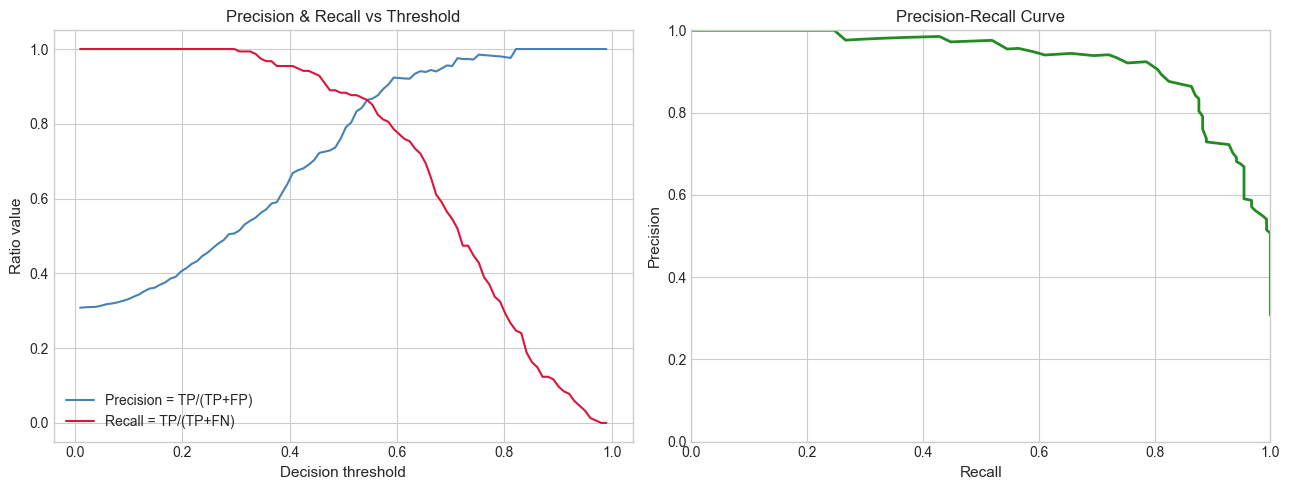

In [4]:
# --- Experiment 1: Precision and recall as ratios ---
# Hypothesis: precision and recall are both ratios, but they trade off against each other.
# A threshold increase raises precision but lowers recall (and vice versa).
# Try changing: THRESHOLD to see the tradeoff.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 500
# Simulated classifier: true labels and predicted scores
true_labels = np.random.binomial(1, 0.3, N)
scores = np.where(true_labels == 1,
                  np.random.beta(5, 2, N),   # positives: higher scores
                  np.random.beta(2, 5, N))   # negatives: lower scores

thresholds = np.linspace(0.01, 0.99, 100)
precisions, recalls = [], []

for t in thresholds:
    pred = (scores >= t).astype(int)
    tp = np.sum((pred == 1) & (true_labels == 1))
    fp = np.sum((pred == 1) & (true_labels == 0))
    fn = np.sum((pred == 0) & (true_labels == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precisions.append(precision)
    recalls.append(recall)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(thresholds, precisions, 'steelblue', label='Precision = TP/(TP+FP)')
axes[0].plot(thresholds, recalls,    'crimson',   label='Recall = TP/(TP+FN)')
axes[0].set_xlabel('Decision threshold', fontsize=11)
axes[0].set_ylabel('Ratio value', fontsize=11)
axes[0].set_title('Precision & Recall vs Threshold', fontsize=12)
axes[0].legend()

axes[1].plot(recalls, precisions, 'forestgreen', linewidth=2)
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

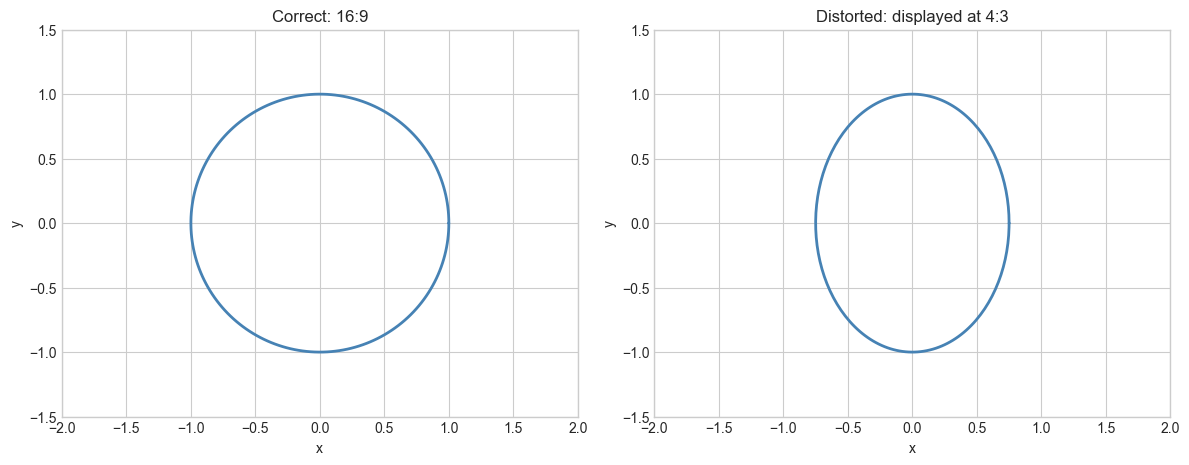

Aspect ratio mismatch factor: 0.750


In [5]:
# --- Experiment 2: Aspect ratio and display distortion ---
# Hypothesis: rendering an image with wrong aspect ratio introduces visible distortion
#             proportional to the ratio mismatch.
# Try changing: DISPLAY_RATIO to see what different aspect ratios do to the circle.

import numpy as np
import matplotlib.pyplot as plt

TRUE_RATIO  = (16, 9)   # native aspect ratio of content
DISPLAY_RATIO = (4, 3)  # <-- modify: try (1,1), (21,9), (16,9)

# Draw a circle in content space; it should remain circular if aspect is correct
theta = np.linspace(0, 2 * np.pi, 200)
cx, cy = np.cos(theta), np.sin(theta)

# Scale x-axis by the ratio mismatch
mismatch = (DISPLAY_RATIO[0] / DISPLAY_RATIO[1]) / (TRUE_RATIO[0] / TRUE_RATIO[1])
cx_distorted = cx * mismatch

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, x, title in zip(axes,
    [cx, cx_distorted],
    [f'Correct: {TRUE_RATIO[0]}:{TRUE_RATIO[1]}',
     f'Distorted: displayed at {DISPLAY_RATIO[0]}:{DISPLAY_RATIO[1]}']):
    ax.plot(x, cy, 'steelblue', linewidth=2)
    ax.set_aspect('equal')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)

plt.tight_layout()
plt.show()
print(f"Aspect ratio mismatch factor: {mismatch:.3f}")

---

## 7. Exercises

**Easy 1.** A server handles 450 requests in 3 minutes. At the same ratio, how many requests does it handle in 1 hour? Use the rule of three.  
*(Expected: 9000)*

**Easy 2.** Convert the aspect ratio 2560:1440 (2K monitor) to its simplest form using the GCD. What is it?  
*(Expected: 16:9)*

**Medium 1.** A model has precision 0.8 and recall 0.6. Compute the F1 score (harmonic mean of precision and recall). Now write a function `f_beta(precision, recall, beta)` that computes the F-beta score, which weights recall β² times more than precision. Plot F_beta vs beta for β in [0.1, 5].  
*(Hint: F_beta = (1 + β²) · P · R / (β²·P + R))*

**Medium 2.** Implement a function `fit_power_law(x, y)` that linearizes by taking logs, fits a line with `np.polyfit`, and returns (k, alpha) such that y ≈ k·x^alpha. Test it on data generated from y = 3·x^2.5 with 5% noise.

**Hard.** The "golden ratio" φ = (1+√5)/2 ≈ 1.618 is the limit of consecutive Fibonacci ratios *(introduced in ch030)*. Prove this algebraically: if φ = lim(F_{n+1}/F_n), then φ must satisfy φ² = φ + 1. Solve this quadratic. Then show computationally that Fibonacci ratios converge to φ and estimate the convergence rate.

---

## 8. Mini Project — Compression Ratio Analyzer

**Problem:** Lossless compression algorithms (gzip, bz2, lzma) achieve different compression ratios depending on data type and content. Your task: build a systematic compression benchmark that computes compression ratio, entropy, and speed for different data types.

**Compression ratio:** `original_size / compressed_size`. Higher is better.

In [ ]:
# --- Mini Project: Compression Ratio Analyzer ---
# Problem: Compare compression ratios across algorithms and data types.
# Dataset: programmatically generated byte sequences of varying entropy.
# Task: complete the entropy calculation and interpret the results.

import gzip, bz2, lzma, zlib
import numpy as np
import matplotlib.pyplot as plt

def entropy_bits(data: bytes) -> float:
    """
    Shannon entropy of a byte sequence in bits/byte.
    H = -sum(p_i * log2(p_i)) for each byte value i.
    Maximum is 8 bits/byte (uniform random).
    """
    if len(data) == 0:
        return 0.0
    counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = counts[counts > 0] / len(data)
    return float(-np.sum(probs * np.log2(probs)))


def compression_ratio(original: bytes, compressed: bytes) -> float:
    """Ratio of original to compressed size. > 1 means compression succeeded."""
    return len(original) / len(compressed)


# Generate different types of test data
N = 100_000
rng = np.random.default_rng(42)

datasets = {
    'uniform random':    rng.integers(0, 256, N, dtype=np.uint8).tobytes(),
    'low entropy (2 vals)': np.where(rng.random(N) < 0.9, 0, 1).astype(np.uint8).tobytes(),
    'sequential':        np.arange(N, dtype=np.uint32).tobytes(),
    'repeated pattern':  (bytes([0, 1, 2, 3, 4]) * (N // 5))[:N],
    'text-like':         bytes([ord(c) for c in ('hello world ' * (N // 12))[:N]]),
}

compressors = {
    'gzip':  lambda d: gzip.compress(d, compresslevel=9),
    'bz2':   lambda d: bz2.compress(d, compresslevel=9),
    'lzma':  lambda d: lzma.compress(d),
    'zlib':  lambda d: zlib.compress(d, level=9),
}

results = {name: {} for name in datasets}

for dname, data in datasets.items():
    results[dname]['entropy'] = entropy_bits(data)
    for cname, compress_fn in compressors.items():
        compressed = compress_fn(data)
        results[dname][cname] = compression_ratio(data, compressed)

# Display
print(f"{'Dataset':<22} {'Entropy':>8}  {'gzip':>6}  {'bz2':>6}  {'lzma':>6}  {'zlib':>6}")
print("-" * 65)
for dname, vals in results.items():
    row = f"{dname:<22} {vals['entropy']:>8.3f}"
    for cname in compressors:
        row += f"  {vals[cname]:>6.2f}x"
    print(row)

# Plot: entropy vs best compression ratio
fig, ax = plt.subplots(figsize=(9, 5))
entropies = [results[d]['entropy'] for d in datasets]
best_ratios = [max(results[d][c] for c in compressors) for d in datasets]

ax.scatter(entropies, best_ratios, s=100, color='steelblue', zorder=3)
for (dname, e, r) in zip(datasets, entropies, best_ratios):
    ax.annotate(dname, (e, r), textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.set_xlabel('Shannon Entropy (bits/byte)', fontsize=11)
ax.set_ylabel('Best compression ratio', fontsize=11)
ax.set_title('Compression Ratio vs Entropy', fontsize=12)
ax.axhline(1.0, color='red', linestyle='--', label='ratio=1 (no compression)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What we covered:**
- Ratios are dimensionless comparisons; proportions are equalities of ratios
- Cross-multiplication tests proportion exactly without floating-point error
- Direct proportion: y/x constant; inverse proportion: x·y constant
- Power laws (y = k·x^α) are the general case — linearize in log-log space
- Compression ratios, precision/recall, aspect ratios are all the same mathematical object

**Backward connection:**  
The `Ratio` class is a thin wrapper over rational number arithmetic *(ch024 — Rational Numbers)*. GCD-based reduction ensures exact comparison without floating-point drift.

**Forward connections:**
- Power law fitting will deepen significantly in **ch043 — Logarithms Intuition**, where log-log linearization is derived formally
- Shannon entropy *(used in the mini project)* is covered rigorously in **ch288 — Entropy** as a measure of information
- Precision and recall as ratios return in **ch283 — Model Evaluation** where the full suite of classification metrics is treated systematically

**Going deeper:** Study *dimensional analysis* — the technique of using ratio constraints to derive physical laws without solving equations. Buckingham's Pi theorem systematizes this into a method.